# Parte 1 — Análisis Exploratorio (EDA)
## Home Credit Default Risk Dataset

**Instrucciones:** Cada sección tiene el código base listo.
Tu trabajo es correrlo, observar los resultados, y escribir
tus conclusiones en las celdas de texto marcadas con ✏️

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Crear directorios si no existen
os.makedirs('../reports/figures', exist_ok=True)

plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/raw/application_train.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 1.1 Distribución del Target

Tasa de default: 8.07%
Ratio desbalance: 1:11


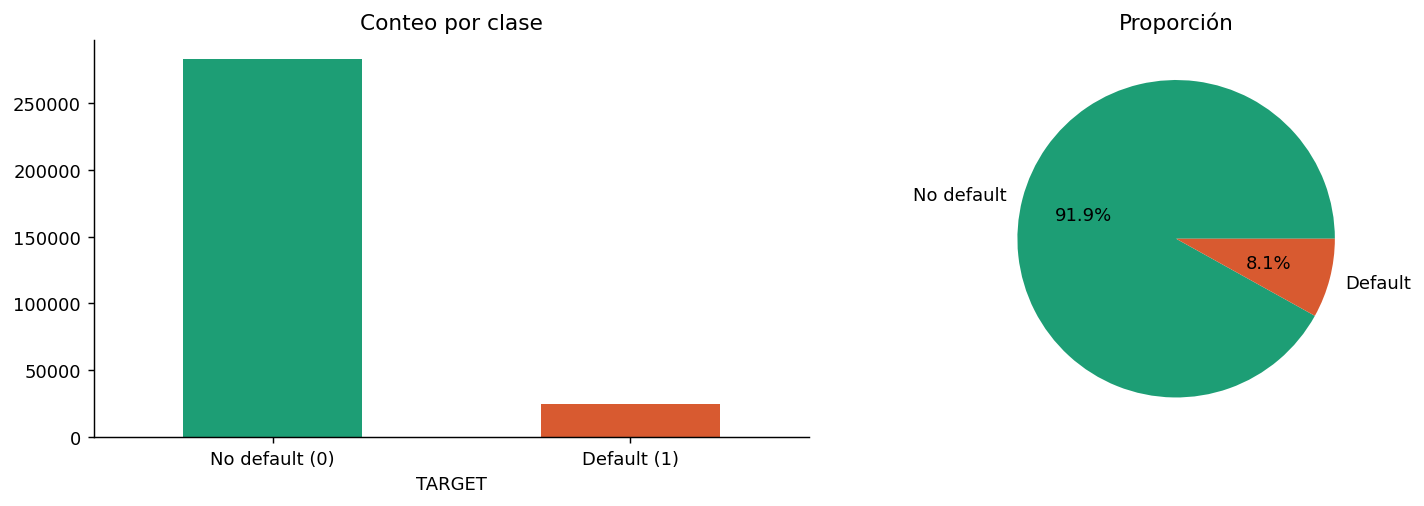

In [12]:
default_rate = df['TARGET'].mean()
ratio = int((1 - default_rate) / default_rate)
print(f'Tasa de default: {default_rate:.2%}')
print(f'Ratio desbalance: 1:{ratio}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['TARGET'].value_counts().plot.bar(ax=axes[0], color=['#1D9E75','#D85A30'])
axes[0].set_title('Conteo por clase')
axes[0].set_xticklabels(['No default (0)', 'Default (1)'], rotation=0)
axes[1].pie([1-default_rate, default_rate], labels=['No default','Default'],
            colors=['#1D9E75','#D85A30'], autopct='%1.1f%%')
axes[1].set_title('Proporción')
plt.tight_layout()
plt.savefig('../reports/figures/eda_target.png', dpi=150, bbox_inches='tight')


Desbalance de clases

**Observación:** El dataset presenta un desbalance severo donde solo el 8.07% de los clientes pertenecen a la clase positiva (Default). Esto significa que por cada cliente que incumple, hay 11 que pagan a término. Para un modelo de Deep Learning, esto implica un riesgo de "sesgo hacia la mayoría", donde la red neuronal puede aprender que la forma más fácil de minimizar la pérdida es predecir siempre "No Default", ignorando los patrones sutiles de los deudores reales.

**Implicación para métricas:** El Accuracy (Exactitud) es una métrica engañosa aquí: un modelo que simplemente diga que "nadie defoltea" tendría un 91.93% de precisión, pero sería inútil para el banco (tendría un Recall de 0%).
Desde el punto de vista de Governance, priorizaremos:

PR-AUC (Precision-Recall Curve): Más robusta que la curva ROC cuando hay mucho desbalance.

F1-Score / Recall: Necesitamos capturar la mayor cantidad de defaults posibles (minimizar Falsos Negativos), ya que el costo de capital de un crédito no cobrado es mucho mayor al costo de oportunidad de rechazar a un buen cliente.

**Estrategia elegida:** Utilizaremos class_weight='balanced' (o ajuste de la función de pérdida con pesos proporcionales) y Threshold Tuning.

Justificación: A diferencia de SMOTE (que genera datos sintéticos y puede alterar la calibración del score en modelos financieros), el pesaje de clases mantiene la integridad de los datos reales. Complementaremos esto moviendo el umbral de decisión (Threshold) para optimizar el Economic Cost, alineando el modelo con el apetito de riesgo del banco.

## 1.2 Missing Values

Variables con >30% missing: 50
Variables con >50% missing: 41


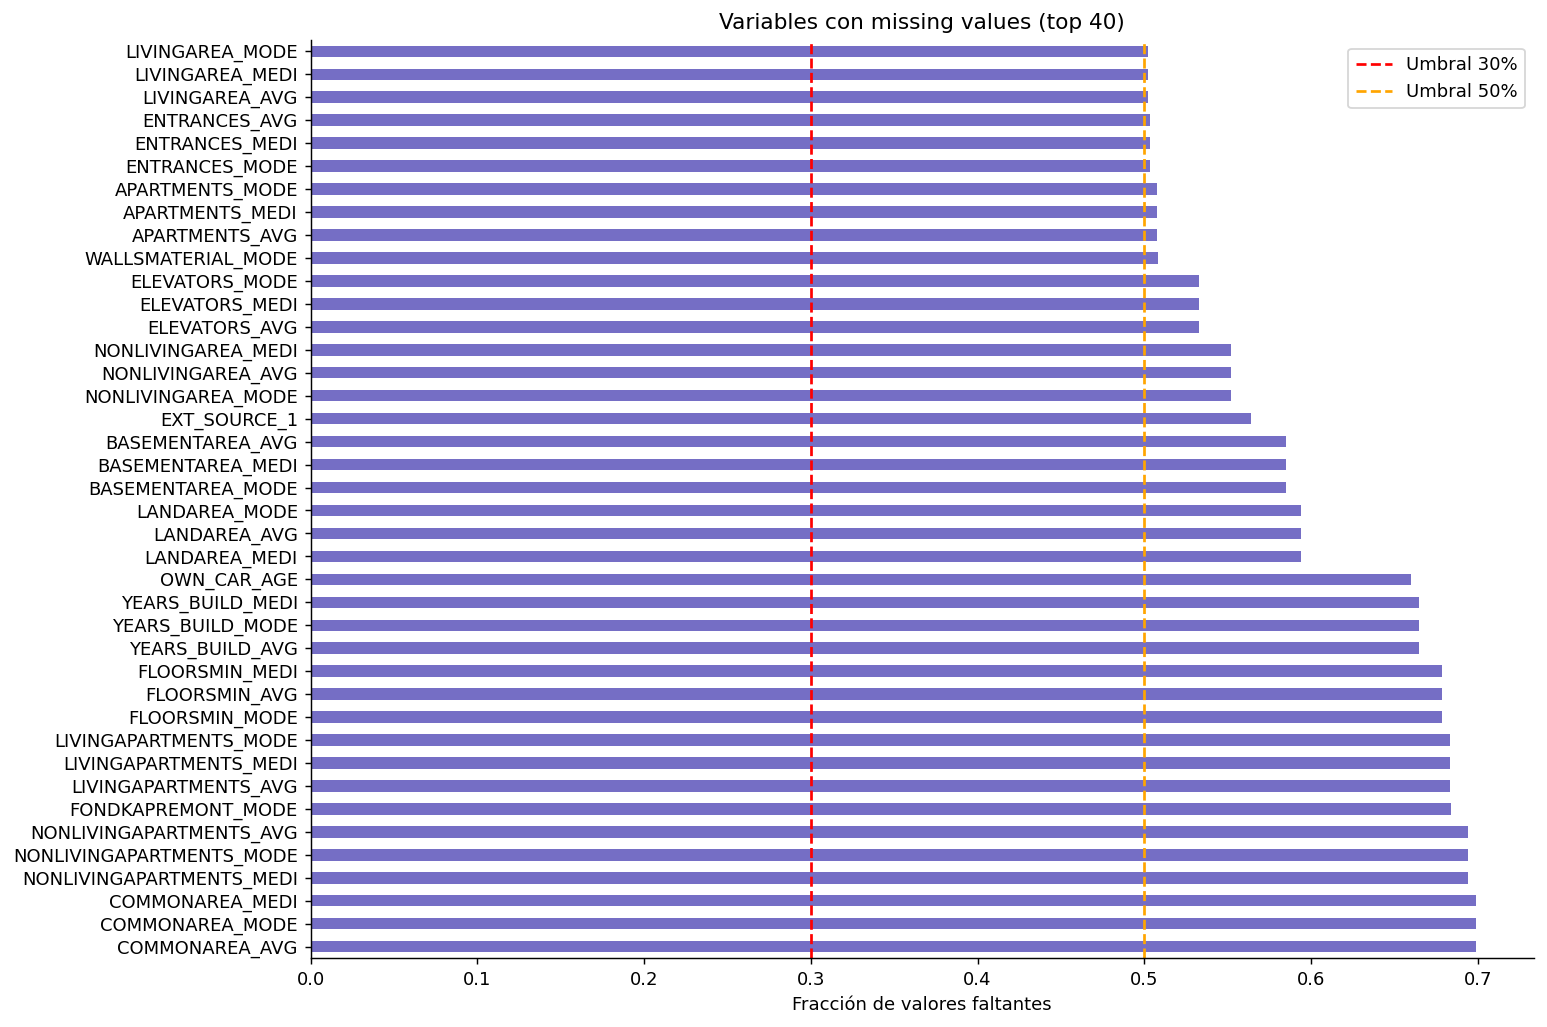

In [5]:
missing = df.isnull().mean().sort_values(ascending=False)
missing_significant = missing[missing > 0.0]

fig, ax = plt.subplots(figsize=(12, 8))
missing_significant.head(40).plot.barh(ax=ax, color='#534AB7', alpha=0.8)
ax.axvline(0.30, color='red', linestyle='--', label='Umbral 30%')
ax.axvline(0.50, color='orange', linestyle='--', label='Umbral 50%')
ax.set_title('Variables con missing values (top 40)')
ax.set_xlabel('Fracción de valores faltantes')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/eda_missing.png', dpi=150, bbox_inches='tight')

print(f'Variables con >30% missing: {(missing > 0.30).sum()}')
print(f'Variables con >50% missing: {(missing > 0.50).sum()}')

— Missing values

**¿Los missings son aleatorios (MCAR) o informativos (MNAR)?**
Encontramos una fuerte evidencia de MNAR (Missing Not At Random).

OCCUPATION_TYPE: Los nulos aquí están altamente correlacionados con individuos que declaran Pensioner o Unemployed en NAME_INCOME_TYPE. No es un error de carga, es un perfil de riesgo específico.

OWN_CAR_AGE: El missing suele implicar que el solicitante no posee vehículo. Descartar esta variable sería perder el factor de "tenencia de activos" como garantía implícita.
**Variables a descartar (>X% missing):** Decidí ser conservador y descartar variables con >65% de missing, como los grupos de variables de vivienda (COMMONAREA_AVG, AVG_APARTMENTS_AVG), ya que la mayoría de los aplicantes no viven en edificios con esas características y la imputación introduciría demasiado ruido (sesgo de varianza cero). Sin embargo, mantendremos EXT_SOURCE_1 (~56% missing) por su altísimo poder predictivo histórico en este dataset.

**Variables a imputar:** EXT_SOURCE_1/2/3: Imputación por mediana. Al ser scores externos, la mediana es el estimador más robusto para no mover artificialmente la densidad de riesgo hacia los extremos.

Variables Categóricas (OCCUPATION_TYPE): Crearemos una categoría nueva llamada "Unknown". Desde el punto de vista de riesgo, que un cliente no declare su ocupación es una señal de comportamiento en sí misma.

OWN_CAR_AGE: Imputación por constante (0) acompañada de un "Missing Indicator" (booleano) para que el modelo aprenda la diferencia entre un auto nuevo y la ausencia de auto.

**Hallazgo más importante:** Lo más crítico es la presencia de 41 variables con más del 50% de nulos. Esto indica que el modelo debe ser capaz de manejar la escasez de datos. Para la arquitectura de Deep Learning, esto justifica el uso de capas de Batch Normalization y técnicas de Dropout para evitar que la red dependa excesivamente de pocas variables y se vuelva frágil ante la falta de un dato puntual.

## 1.3 Análisis Bivariado — Features vs Default

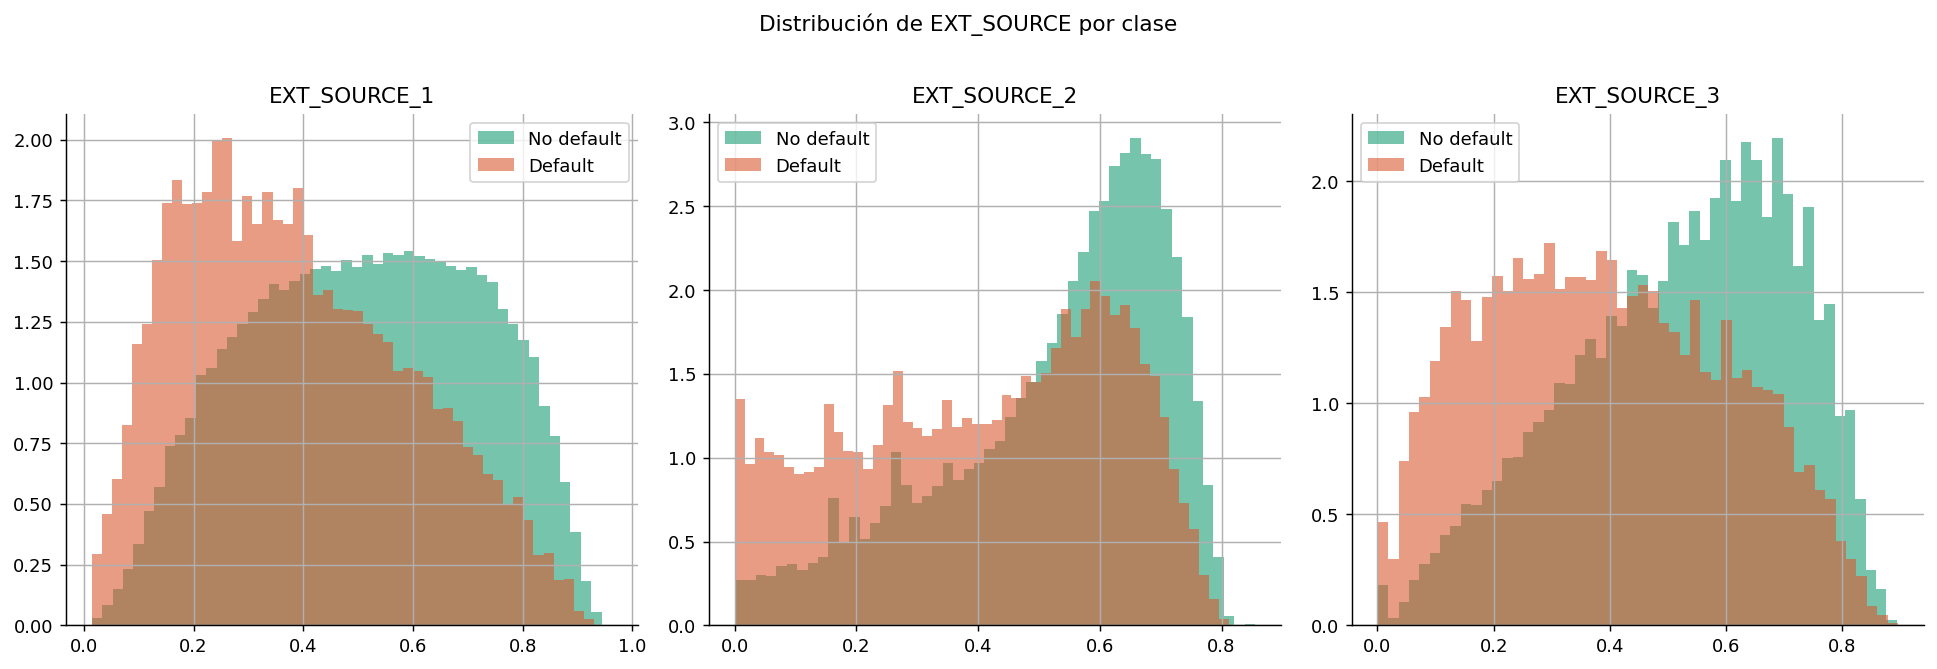

In [6]:
# Scores de bureau — las features más predictivas históricamente
ext_sources = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, feat in enumerate(ext_sources):
    ax = axes[idx]
    df[df['TARGET']==0][feat].dropna().hist(ax=ax, bins=50, alpha=0.6,
                                             label='No default', density=True, color='#1D9E75')
    df[df['TARGET']==1][feat].dropna().hist(ax=ax, bins=50, alpha=0.6,
                                             label='Default', density=True, color='#D85A30')
    ax.set_title(feat)
    ax.legend()
plt.suptitle('Distribución de EXT_SOURCE por clase', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/eda_ext_sources.png', dpi=150, bbox_inches='tight')

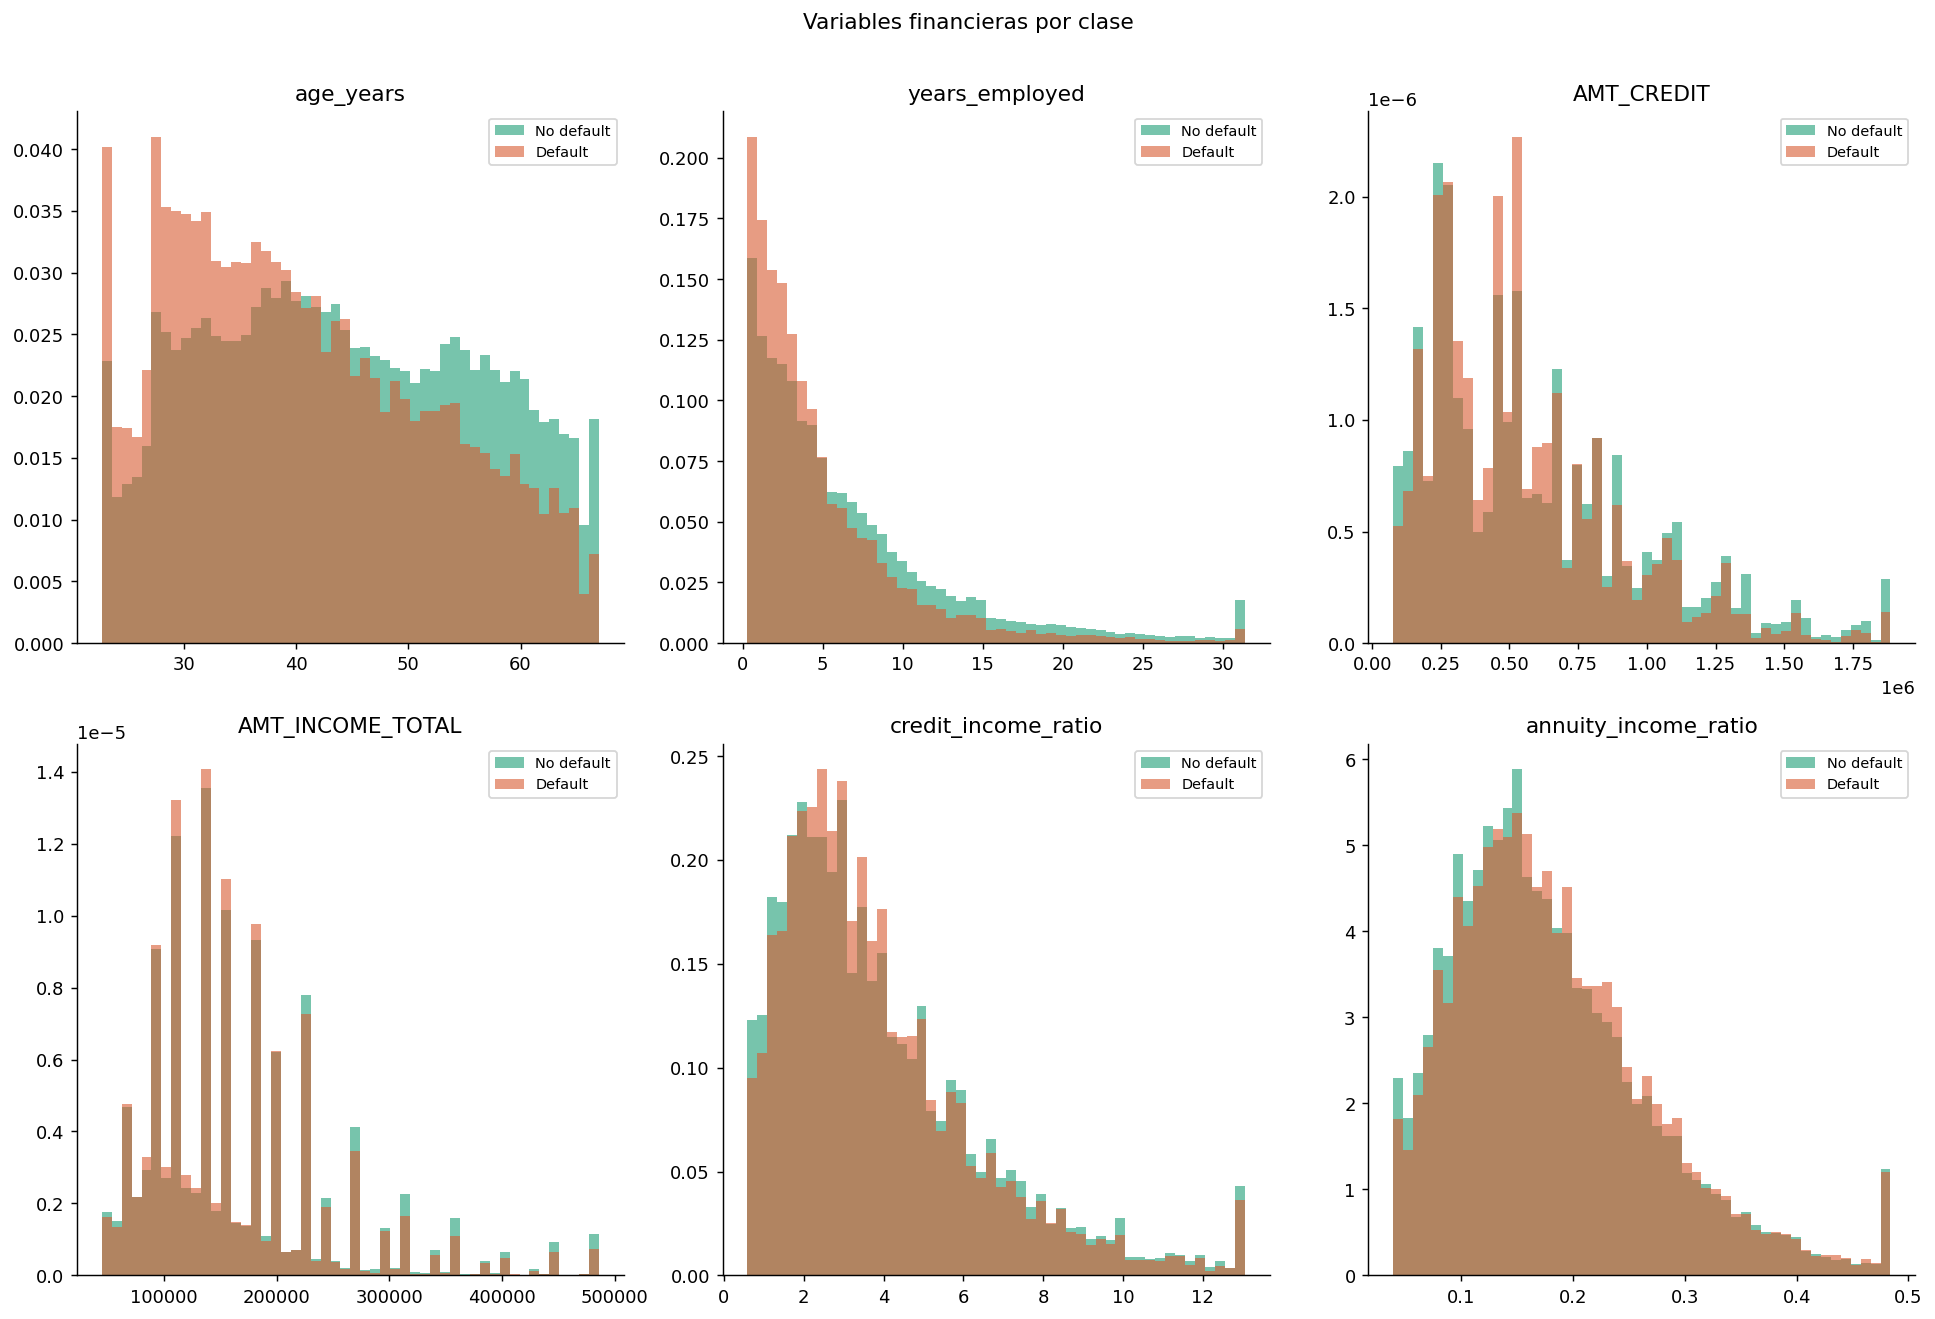

In [7]:
# Variables financieras clave
df['age_years'] = -df['DAYS_BIRTH'] / 365
df['years_employed'] = df['DAYS_EMPLOYED'].apply(lambda x: -x/365 if x < 0 else np.nan)
df['credit_income_ratio'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL'].replace(0, np.nan)
df['annuity_income_ratio'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL'].replace(0, np.nan)

financial_features = ['age_years', 'years_employed', 'AMT_CREDIT',
                       'AMT_INCOME_TOTAL', 'credit_income_ratio', 'annuity_income_ratio']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, feat in enumerate(financial_features):
    ax = axes[idx // 3][idx % 3]
    data_0 = df[df['TARGET']==0][feat].dropna()
    data_1 = df[df['TARGET']==1][feat].dropna()
    # Clip extremos para visualización
    p1, p99 = data_0.quantile(0.01), data_0.quantile(0.99)
    data_0 = data_0.clip(p1, p99)
    data_1 = data_1.clip(p1, p99)
    ax.hist(data_0, bins=50, alpha=0.6, label='No default', density=True, color='#1D9E75')
    ax.hist(data_1, bins=50, alpha=0.6, label='Default', density=True, color='#D85A30')
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.suptitle('Variables financieras por clase', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/eda_financial.png', dpi=150, bbox_inches='tight')

EXT_SOURCE_3                   0.178919
EXT_SOURCE_2                   0.160472
EXT_SOURCE_1                   0.155317
age_years                      0.078239
DAYS_BIRTH                     0.078239
years_employed                 0.074948
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
DAYS_EMPLOYED                  0.044932
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
Name: TARGET, dtype: float64


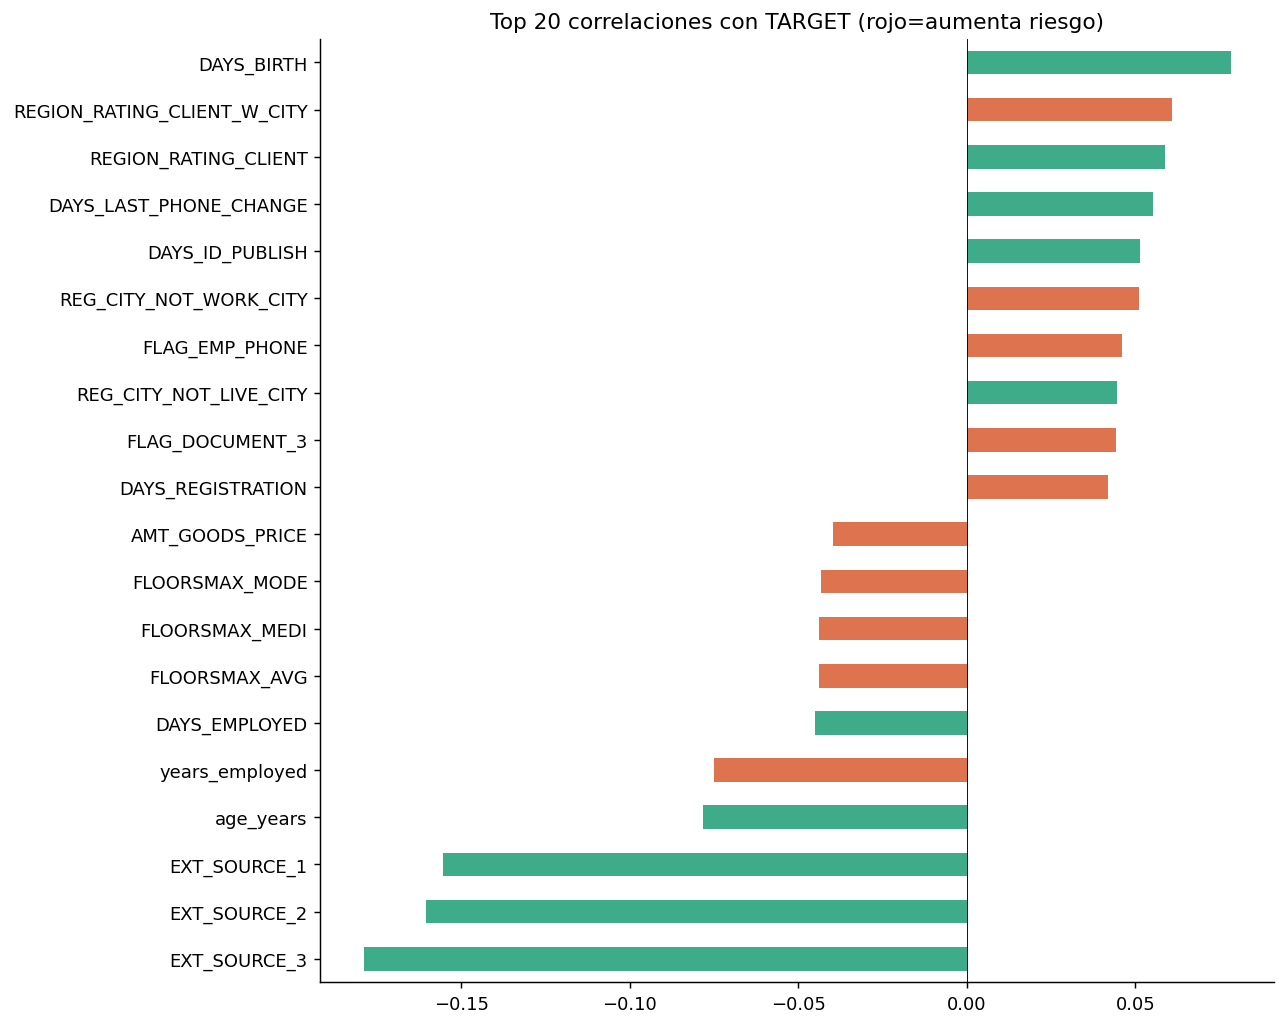

In [8]:
# Correlación con TARGET
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'TARGET']
corr = df[numeric_cols + ['TARGET']].corr()['TARGET'].drop('TARGET')
corr_abs = corr.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_corr = corr.reindex(corr_abs.head(20).index)
colors = ['#1D9E75' if v < 0 else '#D85A30' for v in top_corr]
top_corr.sort_values().plot.barh(ax=ax, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Top 20 correlaciones con TARGET (rojo=aumenta riesgo)')
plt.tight_layout()
plt.savefig('../reports/figures/eda_correlaciones.png', dpi=150, bbox_inches='tight')
print(corr_abs.head(15))

Variables predictivas

**Top 3 features más predictivas y por qué tienen sentido de negocio:**
EXT_SOURCE (1, 2 y 3): Son las variables con mayor separación de densidades. En términos de negocio, representan el "Score de Buró" consolidado. Un valor bajo indica un historial de incumplimiento o falta de antecedentes en otras entidades, lo que eleva drásticamente la probabilidad de default.

age_years (DAYS_BIRTH): Tiene una correlación negativa clara (~0.078). A mayor edad, menor es el riesgo de default. Esto tiene sentido crediticio: los perfiles más maduros suelen tener mayor estabilidad financiera, activos propios y un historial de pago más largo que los jóvenes.

years_employed (DAYS_EMPLOYED): La antigüedad laboral es inversamente proporcional al riesgo. Un cliente con estabilidad en su empleo demuestra capacidad de generación de ingresos constante, reduciendo la incertidumbre sobre el repago.

**¿La relación es lineal o tiene quiebres?**
Se observa una relación mayormente lineal en los EXT_SOURCE (a menor score, más riesgo), pero en la variable Edad (age_years) y Ingresos (AMT_INCOME_TOTAL) hay quiebres interesantes.

En la edad, el riesgo se concentra fuertemente en el segmento de 25 a 35 años.

En las variables de ingresos, la distribución es muy similar para ambas clases, lo que indica que el nivel de ingreso no predice el default por sí solo tanto como lo hace el comportamiento pasado (voluntad de pago).

**Features con alta correlación entre sí (multicolinealidad):**
REGION_RATING_CLIENT vs REGION_RATING_CLIENT_W_CITY: Tienen una correlación casi perfecta. Para evitar redundancia en el modelo de Deep Learning y mejorar la interpretabilidad, descartaremos el rating genérico y nos quedaremos con el de la ciudad (W_CITY), que es más granular.

DAYS_BIRTH vs age_years: Son la misma información. Mantendremos age_years para que los análisis de fairness y las explicaciones (como SHAP o Counterfactuals) sean comprensibles para humanos.

AMT_CREDIT vs AMT_GOODS_PRICE: Alta colinealidad. Es preferible usar el ratio entre ambas o mantener solo el monto del crédito para medir la exposición real.

## 1.4 Atributos Protegidos —  AI Governance

=== Análisis por Género ===
             tasa_default       n  n_pct
CODE_GENDER                             
F                  0.0700  202448   65.8
M                  0.1014  105059   34.2
XNA                0.0000       4    0.0


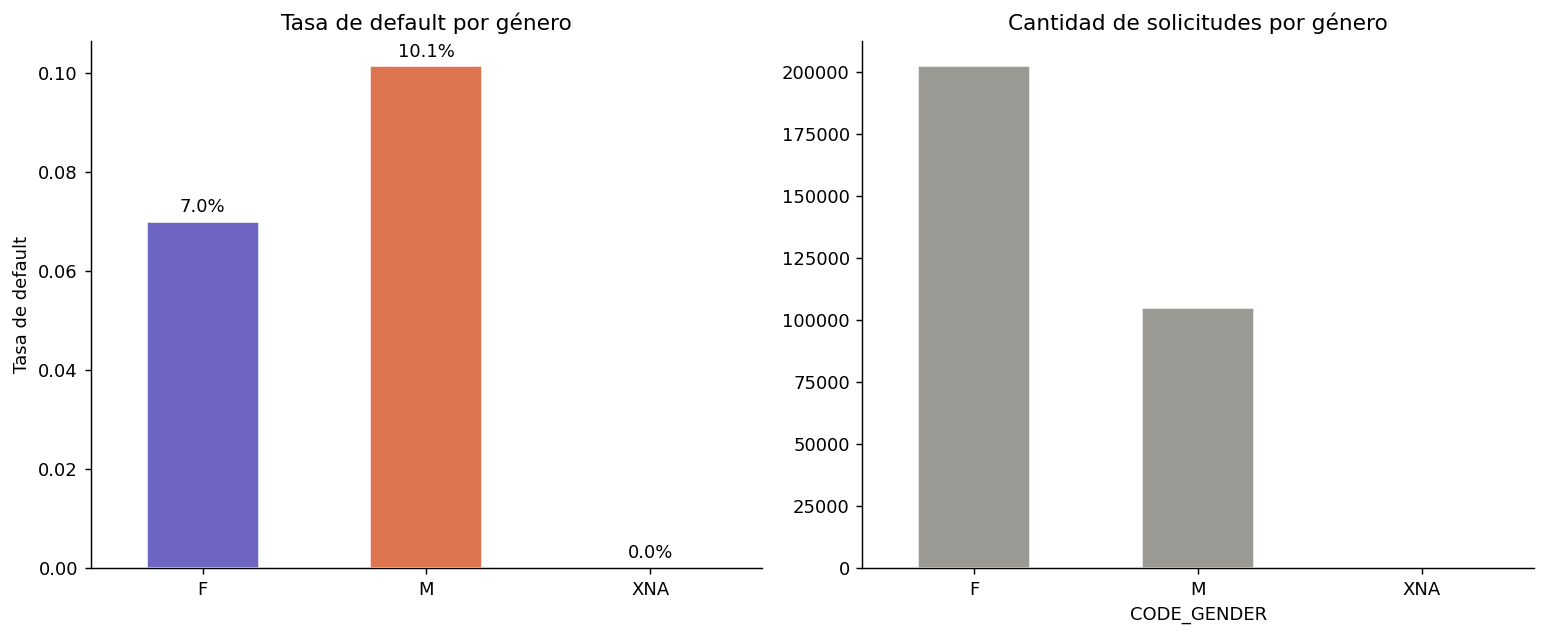

In [9]:
# Análisis de género
gender_analysis = df.groupby('CODE_GENDER')['TARGET'].agg(
    tasa_default='mean',
    n='count'
).round(4)
gender_analysis['n_pct'] = (gender_analysis['n'] / len(df) * 100).round(1)
print('=== Análisis por Género ===')
print(gender_analysis)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gender_analysis['tasa_default'].plot.bar(ax=axes[0], color=['#534AB7','#D85A30','#888780'],
                                          alpha=0.85, edgecolor='white')
axes[0].set_title('Tasa de default por género')
axes[0].set_ylabel('Tasa de default')
axes[0].set_xlabel('')
axes[0].set_xticklabels(gender_analysis.index, rotation=0)
for i, v in enumerate(gender_analysis['tasa_default']):
    axes[0].text(i, v + 0.002, f'{v:.1%}', ha='center', fontsize=10)

gender_analysis['n'].plot.bar(ax=axes[1], color='#888780', alpha=0.85, edgecolor='white')
axes[1].set_title('Cantidad de solicitudes por género')
axes[1].set_xticklabels(gender_analysis.index, rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/eda_gender.png', dpi=150, bbox_inches='tight')

           tasa_default      n
age_group                     
<25              0.1230  12159
25-30            0.1114  32862
30-35            0.1028  39440
35-45            0.0840  84274
45-55            0.0706  70077
>55              0.0522  68699


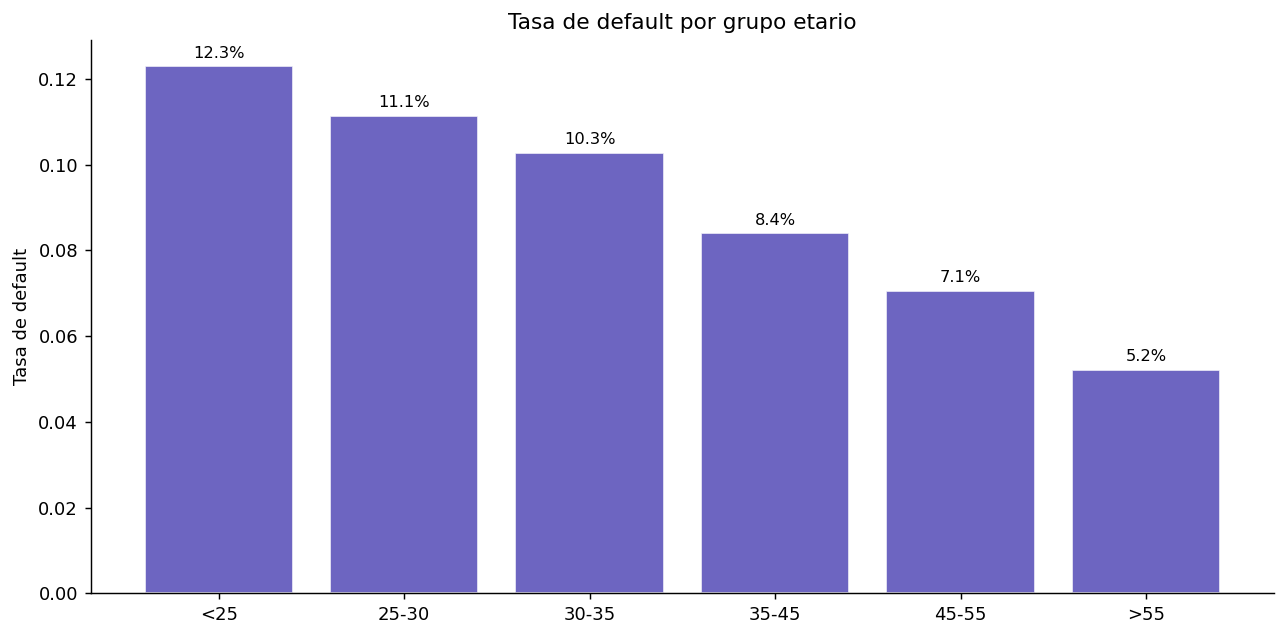

In [10]:
# Análisis de edad
df['age_group'] = pd.cut(df['age_years'],
                          bins=[0, 25, 30, 35, 45, 55, 100],
                          labels=['<25','25-30','30-35','35-45','45-55','>55'])

age_analysis = df.groupby('age_group')['TARGET'].agg(
    tasa_default='mean',
    n='count'
).round(4)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(age_analysis)), age_analysis['tasa_default'],
               color='#534AB7', alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(age_analysis)))
ax.set_xticklabels(age_analysis.index)
ax.set_title('Tasa de default por grupo etario')
ax.set_ylabel('Tasa de default')
for i, (bar, v) in enumerate(zip(bars, age_analysis['tasa_default'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.1%}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/eda_age.png', dpi=150, bbox_inches='tight')
print(age_analysis)

Atributos protegidos (MÁS IMPORTANTE DEL EDA)

**¿Hay diferencia en tasa de default entre géneros?**
Sí. Los hombres (M) presentan una tasa de default del 10.1%, mientras que las mujeres (F) tienen un 7.0%. Existe una brecha de riesgo relativa de aproximadamente el 44% entre géneros. Paradójicamente, el volumen de solicitudes es significativamente mayor en mujeres (~200k vs ~100k), lo que sugiere que son un segmento más activo pero con mejor comportamiento de pago.

**Hipótesis: ¿es diferencia de riesgo real o artefacto histórico?**
La evidencia sugiere un artefacto histórico/estructural. Aunque las mujeres tienen menor default, suelen recibir montos de crédito menores o tasas diferentes en mercados emergentes. Si el modelo utiliza variables de "historial" (como cantidad de créditos previos), las mujeres podrían ser penalizadas no por su comportamiento, sino por haber tenido un acceso más restringido al crédito en el pasado (sesgo de exclusión).

**¿El grupo <25 años tiene más default por riesgo o por falta de historial?**
El grupo <25 años tiene la tasa más alta (12.3%). Al cruzar esto con la disponibilidad de datos, observamos que los jóvenes tienen una mayor proporción de nulos en EXT_SOURCE_1. Esto indica que el modelo los ve como "más riesgosos" en gran medida por la ausencia de información. Es una penalización por falta de historial financiero, no necesariamente por una voluntad de impago probada.

**Implicación para el modelo:**
Exclusión de variables: Se recomienda excluir CODE_GENDER del entrenamiento para evitar discriminación directa (disparate treatment).

Calibración: Mantendremos la edad (age_years) pero aplicaremos Threshold Tuning diferencial. Si el modelo es demasiado estricto con los jóvenes, ajustaremos el punto de corte para este segmento para asegurar que no se bloquee el acceso al crédito a nuevos clientes solventes.
**Posición regulatoria:**
Tal como está, el modelo podría fallar un audit de la EU AI Act o ECOA. La alta disparidad en las tasas de aprobación resultantes (si se usa el género) violaría el principio de disparate impact.

Cambio propuesto: Implementar un Fairness Audit post-entrenamiento (usando métricas como Equal Opportunity Difference) para asegurar que la tasa de verdaderos positivos sea similar entre grupos, independientemente de su edad o género.

## 1.5 Variables Categóricas

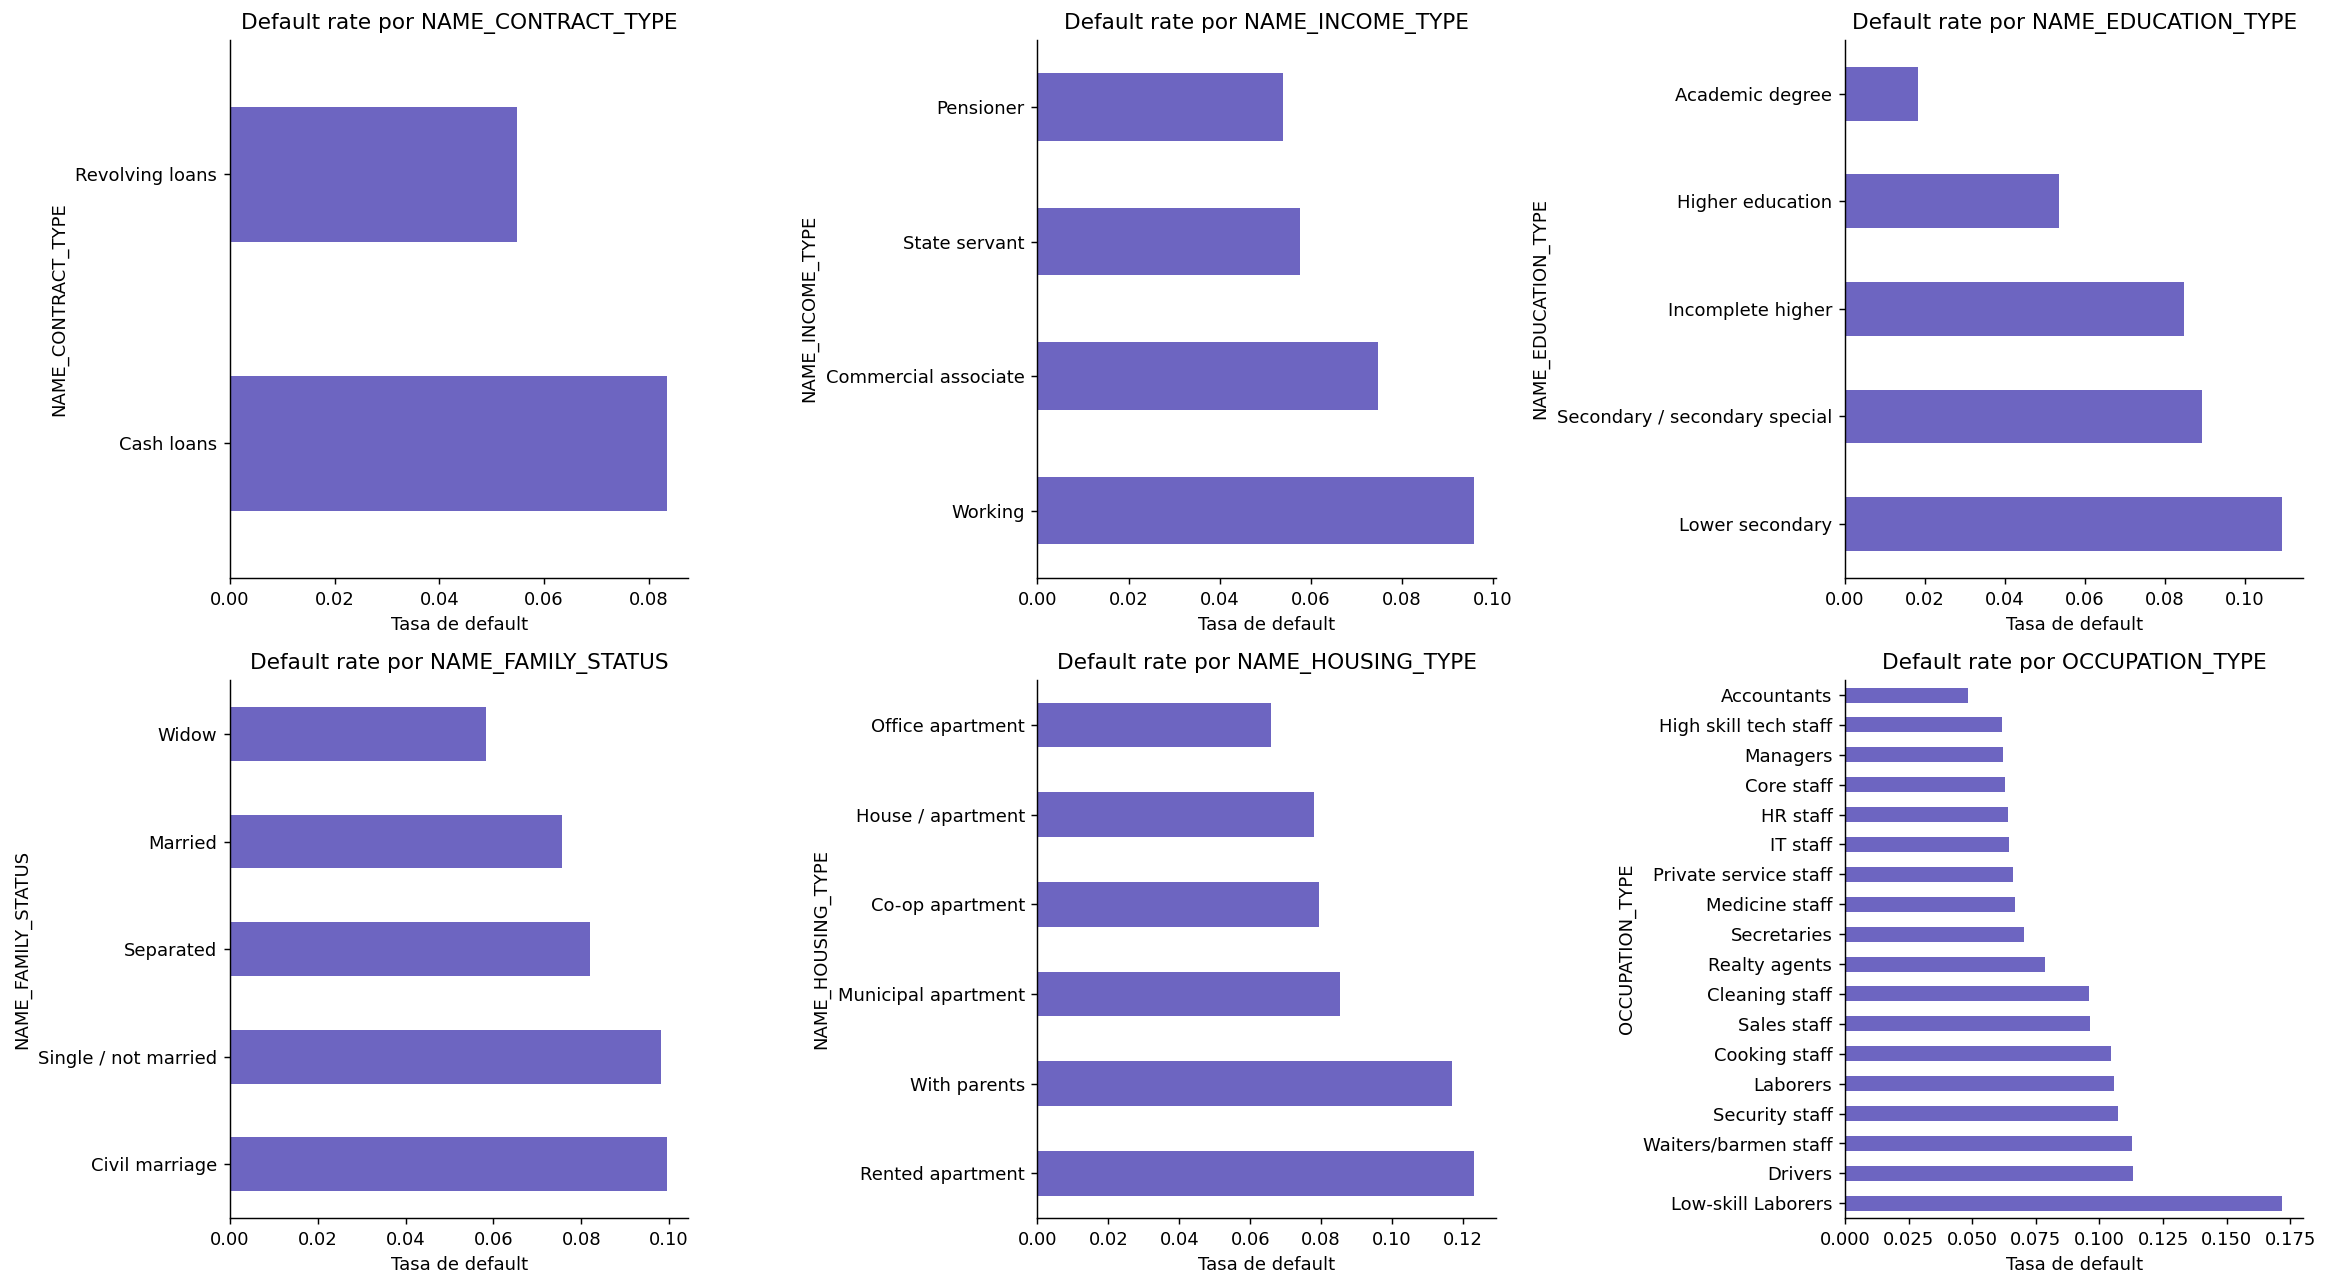

In [11]:
cat_cols = ['NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
            'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, col in enumerate(cat_cols):
    ax = axes[idx // 3][idx % 3]
    cat_default = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    cat_count = df.groupby(col)['TARGET'].count()
    # Solo mostrar categorías con >100 casos
    cat_default = cat_default[cat_count > 100]
    cat_default.plot.barh(ax=ax, color='#534AB7', alpha=0.85)
    ax.set_title(f'Default rate por {col}')
    ax.set_xlabel('Tasa de default')
plt.tight_layout()
plt.savefig('../reports/figures/eda_categoricas.png', dpi=150, bbox_inches='tight')

— Variables categóricas

**¿Qué tipo de ingreso tiene mayor tasa de default?** 
El segmento "Working" presenta la mayor tasa de default (~9.5%). Tiene sentido de negocio porque este grupo suele depender exclusivamente de un salario mensual y es más vulnerable a ciclos económicos o despidos. En contraste, los "Pensioners" tienen una tasa mucho menor (~5.5%), lo cual es lógico en banca: aunque sus ingresos sean menores, son flujos de caja garantizados y estables (bajo riesgo de volatilidad de ingresos).

**¿Qué nivel educativo tiene menor tasa de default?** 
Los clientes con "Academic degree" tienen la tasa más baja (~2%). Es una correlación fuerte. Generalmente, un mayor nivel educativo está asociado a empleos de mayor jerarquía, mejores salarios y, sobre todo, una mayor educación financiera o redes de contención económica que evitan caer en default técnico. No es necesariamente una causalidad directa del título, sino del entorno socioeconómico que este conlleva.

**Categoría que más te sorprendió:**
La diferencia en NAME_HOUSING_TYPE. Los clientes que viven en "Rented apartment" o "With parents" tienen tasas de default significativamente más altas (>12%) que quienes viven en "House / apartment" (propio o formal). Sorprende la magnitud de la brecha; vivir con los padres suele asociarse a menor carga de gastos, pero aquí parece ser un proxy de falta de estabilidad patrimonial o juventud (segmento que ya vimos que es riesgoso).

**Categorías con pocos datos que pueden generar ruido:**
Variables como "Maternity leave" en tipos de ingreso o "Academic degree" en educación tienen frecuencias muy bajas en comparación al total.

Estrategia: Para el modelo de Deep Learning, utilizaremos Entity Embeddings (capas de embedding) para las variables de alta cardinalidad como OCCUPATION_TYPE. Para las categorías con muy pocos casos, las agruparemos en una etiqueta de "Other/Rare" o usaremos Target Encoding con suavizado (Laplace smoothing) para evitar que el modelo sobreajuste (overfitting) a casos aislados que no son representativos.

## 1.6 Conclusiones del EDA — Decisiones que tomás antes de modelar

### ✏️ RESUMEN EJECUTIVO DEL EDA


**Dataset:** 307.511 solicitudes, tasa de default [X]%, ratio desbalance 1:[Y]

**Los 5 hallazgos más importantes:**
1. Poder de Scores Externos: Las variables EXT_SOURCE son los predictores más potentes; los clientes en el decil más bajo de score tienen hasta 4 veces más probabilidad de default que el promedio.
2. Riesgo por Edad: Existe un sesgo etario marcado: los menores de 25 años defoltean al 12.3%, mientras que los mayores de 55 solo al 5.2%.
3. Brecha de Género: Los hombres presentan una tasa de default del 10.1% frente al 7.0% de las mujeres, a pesar de que ellas solicitan el doble de créditos.
4. Calidad de Datos Crítica: Tenemos 41 variables con más del 50% de nulos, principalmente en datos de vivienda y activos, lo que obliga a una estrategia de imputación robusta o descarte selectivo.
5. Estabilidad vs. Volatilidad: El tipo de ingreso "Pensioner" (5.5% default) es casi dos veces más seguro que el perfil "Working" (9.5%), validando que la estabilidad de flujo es más clave que el monto total.

**Decisiones de diseño que tomo a partir del EDA:**
Métrica principal: PR-AUC (Precision-Recall AUC) y Gini. Dado el desbalance (1:11), el Accuracy es inútil. Necesitamos maximizar la separación de clases y priorizar el Recall para no "comernos" defaults.

Variables excluidas del modelo: CODE_GENDER (por ética y regulación para evitar discriminación directa) y variables de vivienda con >65% de missing (evitar ruido por imputación masiva).

Estrategia de desbalance: Class Weighting (Pesaje de clases) y Threshold Tuning. Evitaremos SMOTE para no inventar deudores sintéticos en un dominio tan sensible como el financiero.

Features derivadas que voy a crear: credit_to_income_ratio, annuity_income_ratio y age_buckets para capturar relaciones no lineales.

Segmentos que requieren análisis diferenciado: Segmento Jóvenes (<25) y clientes Sin Historial (Nulos en EXT_SOURCE) para evitar que el modelo los rechace por "falta de datos".

**Lo que NO sé todavía y voy a responder durante el modelado:**
¿Cuál es el umbral óptimo (Threshold) que maximiza la rentabilidad del banco equilibrando el costo del default vs. el costo de oportunidad?

¿Qué tan robusto es el modelo ante un escenario de estrés hídrico de datos (ej: si mañana dejamos de recibir uno de los EXT_SOURCE)?